# AndroZoo Tabular Model Inference

This notebook applies every KronoDroid-trained tabular probe to the balanced AndroZoo temporal hold-out without retraining or refitting preprocessing. It is intended to mirror the sequence-model temporal inference protocol.

In [1]:
# Imports and configuration
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42
N_PER_CLASS = 3000

CANDIDATE_DATA_DIRS = [Path('../androzoo_dataset'), Path('dynamic_ieee_paper/androzoo_dataset'), Path('androzoo_dataset')]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate androzoo_dataset. Run from project root or dynamic_ieee_paper/deneyler.')

BASE_RESULT_DIR = Path('dynamic_ieee_paper/deneyler/results') if Path('dynamic_ieee_paper/deneyler').exists() else Path('results')
MODEL_DIR = BASE_RESULT_DIR / 'tabular_models'
RESULT_DIR = BASE_RESULT_DIR / 'androzoo_tabular_inference'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print('Data directory :', DATA_DIR.resolve())
print('Model directory:', MODEL_DIR.resolve())
print('Result dir     :', RESULT_DIR.resolve())

Data directory : /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/androzoo_dataset
Model directory: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/tabular_models
Result dir     : /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/androzoo_tabular_inference


In [2]:
# Load balanced AndroZoo tabular hold-out
benign_path = DATA_DIR / 'androzoo_benign.csv'
malware_path = DATA_DIR / 'androzoo_malware.csv'

benign = pd.read_csv(benign_path).head(N_PER_CLASS).copy()
malware = pd.read_csv(malware_path).head(N_PER_CLASS).copy()

benign['label'] = 'benign'
malware['label'] = 'malware'

df = pd.concat([benign, malware], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
y = (df['label'] == 'malware').astype(int).to_numpy()

print(f'Benign : {len(benign):,}')
print(f'Malware: {len(malware):,}')
print(f'Total  : {len(df):,}')
print(df['label'].value_counts())

Benign : 3,000
Malware: 3,000
Total  : 6,000
label
benign     3000
malware    3000
Name: count, dtype: int64


In [3]:
# Load KronoDroid-trained tabular model manifest and align feature columns
manifest_path = MODEL_DIR / 'tabular_model_manifest.json'
if not manifest_path.exists():
    raise FileNotFoundError(
        'Missing tabular_model_manifest.json. Run kronodroid_tabular_models.ipynb through the final export cell first.'
    )

with open(manifest_path) as f:
    manifest = json.load(f)

feature_cols = manifest['feature_columns']
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f'AndroZoo tabular data is missing {len(missing)} KronoDroid feature columns: {missing[:10]}')

X = df[feature_cols].copy()
print('Aligned feature count:', X.shape[1])
print('Models:', ', '.join(manifest['models']))

Aligned feature count: 165
Models: LogisticRegression, RandomForest, ExtraTrees, MLP, XGBoost


In [4]:
# Inference helpers
def get_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X_eval)
        return (s - s.min()) / (s.max() - s.min() + 1e-12)
    return model.predict(X_eval)

rows = []
reports = {}
for name, filename in manifest['models'].items():
    model_path = MODEL_DIR / filename
    print()
    print(f'Running {name} from {model_path.name}...')
    model = joblib.load(model_path)
    prob = get_scores(model, X)
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    row = {
        'model': name,
        'accuracy': accuracy_score(y, pred),
        'macro_f1': f1_score(y, pred, average='macro'),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'roc_auc': roc_auc_score(y, prob),
        'pr_auc': average_precision_score(y, prob),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'fpr': fp / (fp + tn + 1e-12),
        'fnr': fn / (fn + tp + 1e-12),
    }
    rows.append(row)
    reports[name] = classification_report(y, pred, target_names=['benign', 'malware'], output_dict=True)

    pred_df = pd.DataFrame({
        'package_name': df.get('package_name', pd.Series(np.arange(len(df)), index=df.index)),
        'true_label': df['label'],
        'y_true': y,
        'malware_probability': prob,
        'y_pred': pred,
        'predicted_label': np.where(pred == 1, 'malware', 'benign'),
    })
    pred_df.to_csv(RESULT_DIR / f'androzoo_tabular_predictions_{name.lower()}.csv', index=False)
    print(pd.Series(row).drop('model').round(4).to_string())

metrics_df = pd.DataFrame(rows).sort_values(['macro_f1', 'roc_auc'], ascending=False)
metrics_df.to_csv(RESULT_DIR / 'androzoo_tabular_metrics_all_models.csv', index=False)
with open(RESULT_DIR / 'androzoo_tabular_classification_reports_all_models.json', 'w') as f:
    json.dump(reports, f, indent=2)

metrics_df


Running LogisticRegression from LogisticRegression.joblib...
accuracy        0.6
macro_f1     0.5869
precision    0.5737
recall       0.7783
roc_auc      0.6638
pr_auc       0.6141
tn             1265
fp             1735
fn              665
tp             2335
fpr          0.5783
fnr          0.2217

Running RandomForest from RandomForest.joblib...
accuracy      0.665
macro_f1     0.6446
precision    0.6116
recall       0.9043
roc_auc      0.7409
pr_auc       0.6785
tn             1277
fp             1723
fn              287
tp             2713
fpr          0.5743
fnr          0.0957

Running ExtraTrees from ExtraTrees.joblib...
accuracy     0.6395
macro_f1     0.6133
precision    0.5918
recall       0.8997
roc_auc      0.7356
pr_auc       0.6695
tn             1138
fp             1862
fn              301
tp             2699
fpr          0.6207
fnr          0.1003

Running MLP from MLP.joblib...
accuracy     0.6365
macro_f1     0.6104
precision    0.5899
recall       0.8953
roc_auc   

,model,accuracy,macro_f1,precision,recall,roc_auc,pr_auc,tn,fp,fn,tp,fpr,fnr
4,XGBoost,0.7075,0.700965,0.660149,0.855333,0.739881,0.706029,1679,1321,434,2566,0.440333,0.144667
1,RandomForest,0.6650,0.644645,0.611587,0.904333,0.740857,0.678489,1277,1723,287,2713,0.574333,0.095667
2,ExtraTrees,0.6395,0.613327,0.591756,0.899667,0.735592,0.669469,1138,1862,301,2699,0.620667,0.100333
3,MLP,0.6365,0.610399,0.589941,0.895333,0.810362,0.810892,1133,1867,314,2686,0.622333,0.104667
0,LogisticRegression,0.6000,0.586861,0.573710,0.778333,0.663753,0.614078,1265,1735,665,2335,0.578333,0.221667


In [5]:
# Compare KronoDroid validation and AndroZoo temporal inference results
source_path = BASE_RESULT_DIR / 'kronodroid_tabular_results.csv'
if source_path.exists():
    source = pd.read_csv(source_path)
    merged = source.merge(metrics_df, on='model', suffixes=('_krono_val', '_androzoo'))
    for metric in ['macro_f1', 'roc_auc', 'fpr', 'fnr']:
        if f'{metric}_krono_val' in merged.columns and f'{metric}_androzoo' in merged.columns:
            merged[f'delta_{metric}'] = merged[f'{metric}_androzoo'] - merged[f'{metric}_krono_val']
    compare_cols = [
        'model',
        'macro_f1_krono_val', 'macro_f1_androzoo', 'delta_macro_f1',
        'roc_auc_krono_val', 'roc_auc_androzoo', 'delta_roc_auc',
        'fpr_krono_val', 'fpr_androzoo', 'delta_fpr',
        'fnr_krono_val', 'fnr_androzoo', 'delta_fnr',
    ]
    compare_cols = [c for c in compare_cols if c in merged.columns]
    comparison = merged[compare_cols].sort_values('macro_f1_androzoo', ascending=False)
    comparison.to_csv(RESULT_DIR / 'tabular_source_vs_androzoo_comparison.csv', index=False)
    display(comparison)
else:
    print('KronoDroid source results not found; skipping source-vs-target comparison.')

,model,macro_f1_krono_val,macro_f1_androzoo,delta_macro_f1,roc_auc_krono_val,roc_auc_androzoo,delta_roc_auc,fpr_krono_val,fpr_androzoo,delta_fpr,fnr_krono_val,fnr_androzoo,delta_fnr
0,XGBoost,0.954443,0.700965,-0.253478,0.983469,0.739881,-0.243589,0.019444,0.440333,0.420889,0.071761,0.144667,0.072905
1,RandomForest,0.954441,0.644645,-0.309795,0.980571,0.740857,-0.239714,0.018519,0.574333,0.555815,0.072693,0.095667,0.022973
2,ExtraTrees,0.953059,0.613327,-0.339732,0.977922,0.735592,-0.242330,0.025000,0.620667,0.595667,0.068966,0.100333,0.031368
3,MLP,0.932133,0.610399,-0.321734,0.954920,0.810362,-0.144558,0.042593,0.622333,0.579741,0.093197,0.104667,0.011470
4,LogisticRegression,0.899518,0.586861,-0.312657,0.936463,0.663753,-0.272710,0.063889,0.578333,0.514444,0.136999,0.221667,0.084668


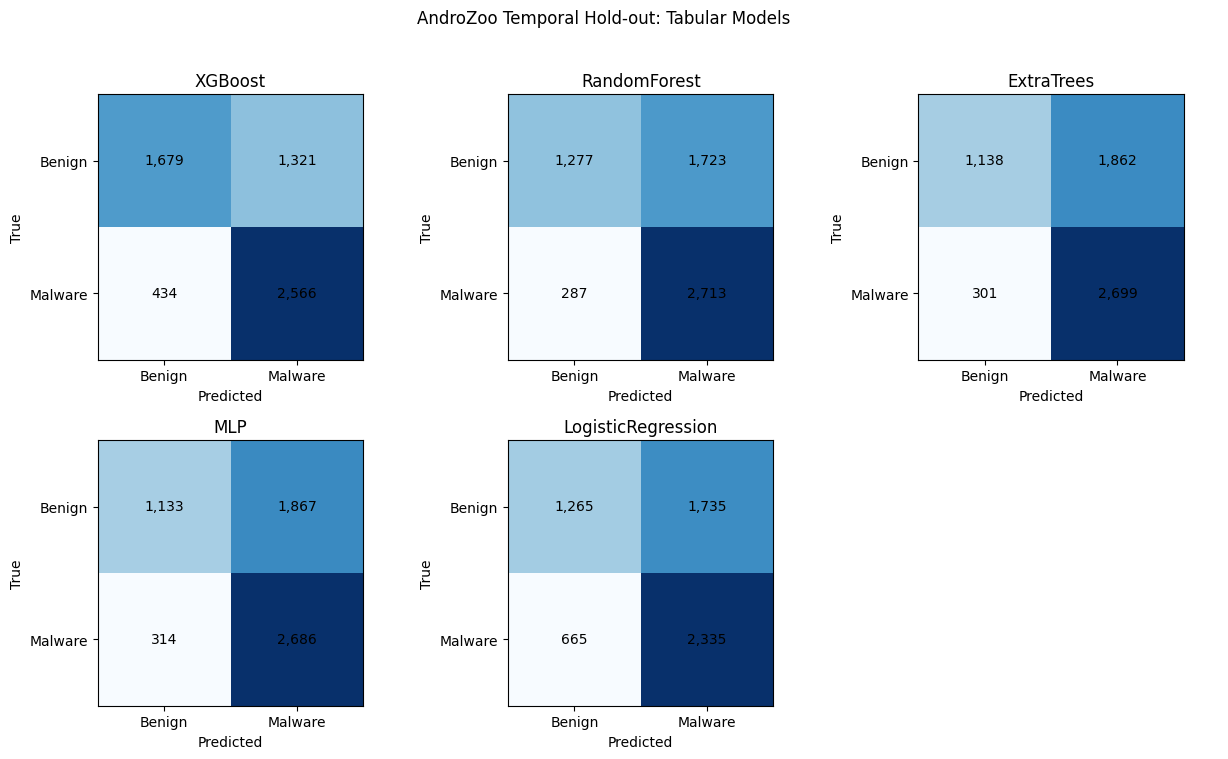

In [6]:
# Confusion matrices for paper artifacts
import matplotlib.pyplot as plt

n = len(metrics_df)
cols = min(3, n)
rows_n = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(4.2 * cols, 3.7 * rows_n))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, metrics_df.iterrows()):
    cm = np.array([[int(row['tn']), int(row['fp'])], [int(row['fn']), int(row['tp'])]])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(row['model'])
    ax.set_xticks([0, 1], labels=['Benign', 'Malware'])
    ax.set_yticks([0, 1], labels=['Benign', 'Malware'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', color='black')

for ax in axes[n:]:
    ax.axis('off')

fig.suptitle('AndroZoo Temporal Hold-out: Tabular Models', y=1.02)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'androzoo_tabular_confusion_matrices_all_models.pdf', bbox_inches='tight')
fig.savefig(RESULT_DIR / 'androzoo_tabular_confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()